In [263]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 30)

##  Load Data : 

In [264]:
df=pd.read_csv(r"D:\DATA SETS (Project)\Amazon_sales.csv")
df.head(3)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015...,True,NaN,NaN


## Basic Inspection : 

In [265]:
print(df.shape)
print('-'*50,'Data Type','-'*50)
print(df.dtypes)
print('-'*50,'Null Values','-'*50)
print(df.isnull().sum())
print('-'*50,'Stats','-'*50)
print(df.describe())
print('-'*50,'Duplicate Values','-'*50)
print(df.duplicated().sum())

(128975, 24)
-------------------------------------------------- Data Type --------------------------------------------------
index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
promotion-ids          object
B2B                      bool
fulfilled-by           object
Unnamed: 22            object
dtype: object
-------------------------------------------------- Null Values --------------------------------------------------
index                     0

##  Data Cleaning : 

#### Clean Column Name : 

In [266]:
df.columns=(df.columns
            .str.strip()
            .str.replace(' ','_')
            .str.replace('-','_')
            .str.title())
df.columns

Index(['Index', 'Order_Id', 'Date', 'Status', 'Fulfilment', 'Sales_Channel',
       'Ship_Service_Level', 'Style', 'Sku', 'Category', 'Size', 'Asin',
       'Courier_Status', 'Qty', 'Currency', 'Amount', 'Ship_City',
       'Ship_State', 'Ship_Postal_Code', 'Ship_Country', 'Promotion_Ids',
       'B2B', 'Fulfilled_By', 'Unnamed:_22'],
      dtype='object')

#### Fixed Date : 

In [267]:
df['Date']= pd.to_datetime(df['Date'],dayfirst=False,errors='coerce')

#### Fix Data Types : 

In [268]:
# To check which column need to convert :
for col in df.columns:
    print(col,df[col].nunique())

Index 128975
Order_Id 120378
Date 91
Status 13
Fulfilment 2
Sales_Channel 2
Ship_Service_Level 2
Style 1377
Sku 7195
Category 9
Size 11
Asin 7190
Courier_Status 3
Qty 10
Currency 1
Amount 1410
Ship_City 8955
Ship_State 69
Ship_Postal_Code 9459
Ship_Country 1
Promotion_Ids 5787
B2B 2
Fulfilled_By 1
Unnamed:_22 1


In [269]:
# Change this columns to categorical column 
cols=['Status','Sales_Channel','Courier_Status','Fulfilment','ship_service_level','Category','Size','B2B']
for col in cols:
    if col in df.columns:
        df[col]=df[col].astype('category')
        
# change this columns to numerical
df['Qty']=pd.to_numeric(df['Qty'], errors ='coerce')
df['Amount']=pd.to_numeric(df['Amount'], errors = 'coerce')

# drop useless column
df.drop(columns=['Unnamed:_22'], inplace= True)
# drop use less rows:
df=df.dropna(subset=['Ship_Country'])

#### Fill Nulls and Repalce : 

In [270]:
df['Currency'].fillna('INR', inplace = True)
df['Amount'].fillna(0, inplace = True)
df['Promotion_Ids'].fillna('No Promotion' , inplace = True)
df['Fulfilled_By'].fillna('Amazon' , inplace= True)
# Create new category : 
df['Courier_Status']=df['Courier_Status'].cat.add_categories(['Pending'])
# Then fill null
df['Courier_Status'].fillna('Pending' , inplace = True)

#### Clean columns text

In [271]:
df.columns

Index(['Index', 'Order_Id', 'Date', 'Status', 'Fulfilment', 'Sales_Channel',
       'Ship_Service_Level', 'Style', 'Sku', 'Category', 'Size', 'Asin',
       'Courier_Status', 'Qty', 'Currency', 'Amount', 'Ship_City',
       'Ship_State', 'Ship_Postal_Code', 'Ship_Country', 'Promotion_Ids',
       'B2B', 'Fulfilled_By'],
      dtype='object')

In [272]:
# Checking Ship Country Column
df['Ship_Country']=df['Ship_Country'].replace('IN' , 'India')

In [273]:
# Checking Status Column 
print(df['Status'].unique())
# Create mapping dictionary for replace
status_map = {
    'Shipped - Delivered to Buyer'      : 'Delivered',
    'Shipped'                           : 'In Progress',
    'Shipping'                          : 'In Progress',
    'Shipped - Picked Up'               : 'In Progress',
    'Shipped - Out for Delivery'        : 'In Progress',
    'Pending'                           : 'Pending',
    'Pending - Waiting for Pick Up'     : 'Pending',
    'Cancelled'                         : 'Cancelled',
    'Shipped - Returned to Seller'      : 'Returned',
    'Shipped - Returning to Seller'     : 'Returned',
    'Shipped - Rejected by Buyer'       : 'Returned',
    'Shipped - Damaged'                 : 'Returned',
    'Shipped - Lost in Transit'         : 'Returned'
}
# Apply Mapping and chek
df['Status']=df['Status'].replace(status_map)
print(df['Status'].unique())
print(df['Status'].value_counts())

['Cancelled', 'Shipped - Delivered to Bu..., 'Shipped', 'Shipped - Returned to Sel..., 'Shipped - Rejected by Buyer', ..., 'Shipped - Picked Up', 'Pending', 'Pending - Waiting for Pic..., 'Shipped - Damaged', 'Shipping']
Length: 13
Categories (13, object): ['Cancelled', 'Pending', 'Pending - Waiting for Pic..., 'Shipped', ..., 'Shipped - Rejected by Buyer', 'Shipped - Returned to Sel..., 'Shipped - Returning to Se..., 'Shipping']
['Cancelled', 'Delivered', 'In Progress', 'Returned', 'Pending']
Categories (5, object): ['Cancelled', 'Pending', 'In Progress', 'Returned', 'Delivered']
Status
In Progress    78804
Delivered      28762
Cancelled      18325
Returned        2112
Pending          939
Name: count, dtype: int64


In [274]:
# Checking ship state
print(df['Ship_State'].unique())
# Convert to title case and stip hidden spaces 
df['Ship_State']=df['Ship_State'].str.strip().str.title()
# Create maping dictionary for replace
state_maping={
   'Rajshthan'              : 'Rajasthan',
   'Rajsthan'               : 'Rajasthan',
   'Rajshthan'              : 'Rajasthan',
   'orissa'                 : 'Odisha',
    'Orissa'                : 'Odisha',
   'Pondicherry'            : 'Puducherry',
   'New Delhi'              : 'Delhi',
   'Punjab/Mohali/Zirakpur' : 'Punjab',
   'Nl'                     : 'Nagaland',
   'Rj'                     : 'Rajasthan',
   'Pb'                     : 'Punjab',
   'Ar'                     : 'Arunachal Pradesh',
   'bihar'                  :'Bihar',
    'Dadra And Nagar'       :'Dadra & Nagar Haveli' ,
   'Apo'                    : None,
}
# apply  mapping
df['Ship_State']=df['Ship_State'].replace(state_maping)
df=df.dropna(subset=['Ship_State'])
print(df['Ship_State'].unique())
print(df['Ship_State'].value_counts())

['MAHARASHTRA' 'KARNATAKA' 'PUDUCHERRY' 'TAMIL NADU' 'UTTAR PRADESH'
 'CHANDIGARH' 'TELANGANA' 'ANDHRA PRADESH' 'RAJASTHAN' 'DELHI' 'HARYANA'
 'ASSAM' 'JHARKHAND' 'CHHATTISGARH' 'ODISHA' 'KERALA' 'MADHYA PRADESH'
 'WEST BENGAL' 'NAGALAND' 'Gujarat' 'UTTARAKHAND' 'BIHAR'
 'JAMMU & KASHMIR' 'PUNJAB' 'HIMACHAL PRADESH' 'ARUNACHAL PRADESH'
 'MANIPUR' 'Goa' 'MEGHALAYA' 'GOA' 'TRIPURA' 'LADAKH' 'DADRA AND NAGAR'
 'SIKKIM' 'Delhi' 'ANDAMAN & NICOBAR ' 'Punjab' 'Rajshthan' 'Manipur'
 'rajasthan' 'Odisha' 'NL' 'Bihar' 'MIZORAM' 'punjab' 'New Delhi'
 'Rajasthan' 'Punjab/Mohali/Zirakpur' 'Puducherry' 'delhi' 'RJ'
 'Chandigarh' 'orissa' 'LAKSHADWEEP' 'goa' 'PB' 'APO' 'Arunachal Pradesh'
 'AR' 'Pondicherry' 'Sikkim' 'Arunachal pradesh' 'Nagaland' 'bihar'
 'Mizoram' 'rajsthan' 'Orissa' 'Rajsthan' 'Meghalaya']
['Maharashtra' 'Karnataka' 'Puducherry' 'Tamil Nadu' 'Uttar Pradesh'
 'Chandigarh' 'Telangana' 'Andhra Pradesh' 'Rajasthan' 'Delhi' 'Haryana'
 'Assam' 'Jharkhand' 'Chhattisgarh' 'Odisha' 'Keral

In [275]:
# Checking Ship Postal Code
print(df['Ship_Postal_Code'].unique())
print(df['Ship_Postal_Code'].dtype)
print(df['Ship_Postal_Code'].value_counts())
# Change data type and revome decimal
df['Ship_Postal_Code']=df['Ship_Postal_Code'].astype(int).astype(str).str.zfill(6)
# Check again
df['Ship_Postal_Code'].unique()[:5]

[400081. 560085. 410210. ... 609603. 851205. 629152.]
float64
Ship_Postal_Code
201301.0    1006
122001.0     688
560037.0     632
560068.0     619
560076.0     581
            ... 
841232.0       1
781123.0       1
516329.0       1
207245.0       1
680322.0       1
Name: count, Length: 9458, dtype: int64


array(['400081', '560085', '410210', '605008', '600073'], dtype=object)

In [276]:
# Checking Ship City Column
df['Ship_City'].unique()
# Strip and title for better analysis
df['Ship_City']=df['Ship_City'].str.strip().str.title()

In [277]:
# Checking Promotion ID column:
print(df['Promotion_Ids'].value_counts())
# Create Function :
def Promotion_Category(x):
    if x=='No Promotion':
        return 'No Promotion'
    elif 'Free Shipping' in str(x):
        return 'Free Shipping'
    elif 'PLCC' in str(x):
        return 'Credit Card Offer'
    else :
        return 'Coupon/Other Offer'
# Create new column : 
df['Promotion_Type']=df['Promotion_Ids'].apply(Promotion_Category)
# Check again
df['Promotion_Type'].value_counts()

Promotion_Ids
No Promotion                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

Promotion_Type
No Promotion          49144
Free Shipping         46183
Credit Card Offer     32338
Coupon/Other Offer     1276
Name: count, dtype: int64

In [278]:
# Checking B2B column 
df['B2B'].unique()

[False, True]
Categories (2, bool): [False, True]

In [279]:
# Checking fulfilled by column
print(df['Fulfilled_By'].unique())
# Replace and fill
df['Fulfilled_By']=df['Fulfilled_By'].replace('Amazon',np.nan)
df['Fulfilled_By'].fillna('Merchant',inplace = True)
df['Fulfilled_By'].value_counts()

['Easy Ship' 'Amazon']


Fulfilled_By
Merchant     89677
Easy Ship    39264
Name: count, dtype: int64

In [280]:
# Checking Qty Column 
print(df['Qty'].value_counts())
# To see the null
print(df[df['Qty']==0]['Status'].value_counts())
# Checking Where Qty is zero and status is not cancelled: 
print(df[((df['Qty']==0) & (df['Status']!='Cancelled'))].shape[0])
# Drop rows where Qty is zero and status is not calcelled
df=df[~((df['Qty']==0) & (df['Status']!='Cancelled'))]
df.shape

Qty
1     115752
0      12801
2        341
3         32
4          9
5          2
9          1
15         1
13         1
8          1
Name: count, dtype: int64
Status
Cancelled      12695
In Progress       93
Delivered          8
Returned           3
Pending            2
Name: count, dtype: int64
106


(128835, 24)

In [281]:
# Checking Amount Column 
print(df['Amount'].describe())
# Checking zero amount count
print(df[df['Amount']== 0 ]['Status'].value_counts())
# Checking where Amount is null but status is not cancelled
print(df[(df['Amount']==0) & ( df['Status']!='Cancelled')][['Order_Id','Status','Courier_Status','Qty','Amount','Category',]].head(10))
# Calculating median for each Category
category_median=df[(df['Amount']>0)].groupby('Category')['Amount'].median()
# filling zero amount with median  where status is not cancelled
df['Amount']=np.where(
    (df['Amount']==0) & (df['Status']!= 'Cancelled'),
    df['Category'].map(category_median),
    df['Amount']
)
# Verify
print(df[df['Amount']==0]['Status'].value_counts())

count    128835.000000
mean        609.880912
std         312.994720
min           0.000000
25%         414.290000
50%         586.000000
75%         771.000000
max        5584.000000
Name: Amount, dtype: float64
Status
Cancelled      7563
In Progress    1669
Delivered       716
Returned         55
Pending          26
Name: count, dtype: int64
                Order_Id       Status Courier_Status  Qty  Amount  \
212  408-4547464-4180323    Delivered        Shipped    1     0.0   
374  408-5020509-5674715     Returned        Shipped    1     0.0   
385  408-3137526-3167563  In Progress        Shipped    1     0.0   
388  408-7971979-8745937    Delivered        Shipped    1     0.0   
392  408-0912805-7526753  In Progress        Shipped    1     0.0   
436  408-6466311-6949931  In Progress        Shipped    1     0.0   
441  408-6732772-4525113    Delivered        Shipped    1     0.0   
446  408-7937211-8974712  In Progress        Shipped    1     0.0   
449  408-6348199-2089932  In Prog

# EDA : 

## SECTION 1 - Sales & Revenue Analysis : 

This section Contains :

- KPI Summary-like the total revenue, orders, and average order value
- Revenue trend over time (daily, weekly, monthly)
- Which days of the week see the most sales
- What is the revenue split between fulfilment types

#### CELL 1 -KPI Summary

In [282]:
total_revenue=df['Amount'].sum()
total_orders=df['Order_Id'].nunique()
total_unit=df['Qty'].sum()
avg_order_val=df[df['Amount'] > 0]['Amount'].mean()
cancelled=df[df['Status']== 'Cancelled'].shape[0]
cancel_rate=cancelled * 100/len(df)
revenue_lost=df[df['Status']== 'Cancelled']['Amount'].sum()
print('-'*50,'AMAZON SALES — KPI SUMMARY','-'*50)
print(f" Total Revenue :{total_revenue : .2f}")
print(f" Total Orders :{total_orders }")
print(f" Total Unit :{total_unit : }")
print(f" Average Order Value :{avg_order_val : .2f}")
print(f" No. of Cancelled Order :{cancelled}")
print(f" Cancellation Rate : {cancel_rate: .2f}")
print(f" Revenue Lost:{revenue_lost : .2f}")
print('-'*60,'END','-'*60)

-------------------------------------------------- AMAZON SALES — KPI SUMMARY --------------------------------------------------
 Total Revenue : 80130308.30
 Total Orders :120349
 Total Unit : 116621
 Average Order Value : 660.75
 No. of Cancelled Order :18324
 Cancellation Rate :  14.22
 Revenue Lost: 6917254.30
------------------------------------------------------------ END ------------------------------------------------------------


#### Cell 2 - Daily Revenue Trend

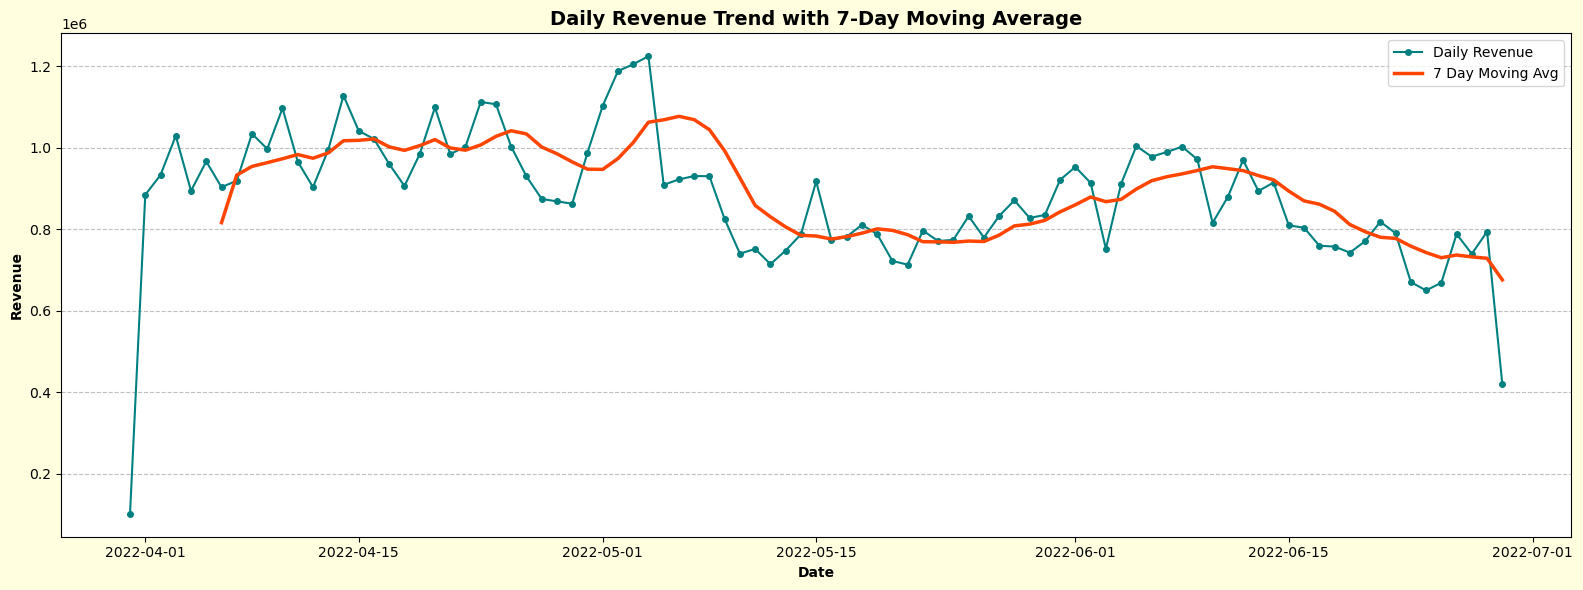

In [283]:
day_rev=df.groupby('Date')['Amount'].sum().reset_index()
day_rev['7day_avg']=day_rev['Amount'].rolling(7).mean()
# Daily Revenue Trend in line plot
plt.figure(figsize=(16,6),facecolor='lightyellow')
plt.plot(day_rev['Date'],day_rev['Amount'],
         color='teal',
         marker='o',
        markersize=4,
        label='Daily Revenue')
# 7 Day Average in line plot
plt.plot(day_rev['Date'],day_rev['7day_avg'],
         color='orangered',
         label='7 Day Moving Avg',
         linewidth=2.5)
plt.title('Daily Revenue Trend with 7-Day Moving Average', fontsize=14,fontweight='bold')
plt.xlabel('Date',fontweight='bold')
plt.ylabel('Revenue',fontweight='bold')
plt.grid(True,axis='y', linestyle='--', alpha=0.5, color='gray')
plt.legend()
plt.tight_layout() 
plt.show()

#### CELL 3 - Day of Week : Sales & Orders

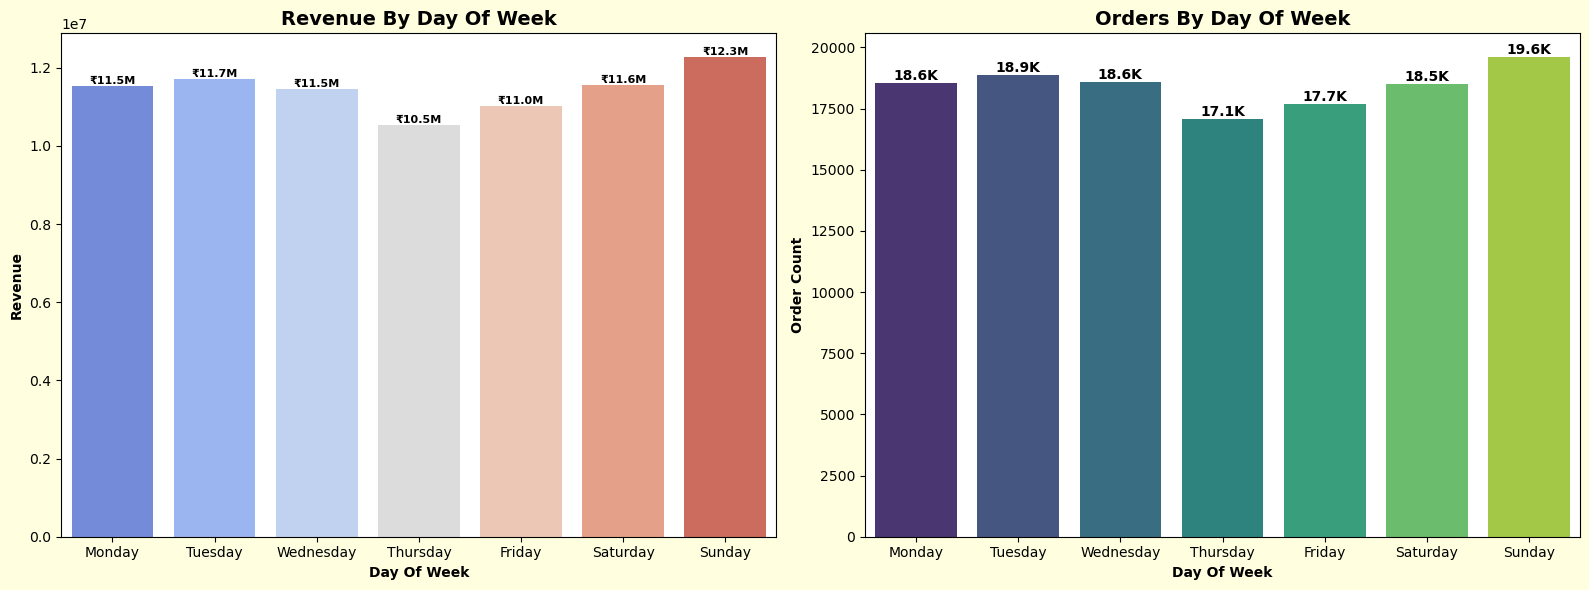

In [284]:
# Create new column Day of Week
df['Day_Of_Week']=df['Date'].dt.strftime('%A')
# Define Correct Order
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
# Group by Days
Day_summary=df.groupby('Day_Of_Week').agg(
    Revenue=('Amount','sum'),
    Order_count=('Order_Id','count')).reindex(day_order).reset_index()
fig,axes=plt.subplots(1,2,figsize=(16,6),facecolor='lightyellow')
# First plot
sns.barplot(data=Day_summary,x='Day_Of_Week', y='Revenue',palette='coolwarm', order=day_order, ax=axes[0])
axes[0].set_title('Revenue By Day Of Week',fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day Of Week',fontweight='bold')
axes[0].set_ylabel('Revenue',fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'₹{p.get_height()/1e6:.1f}M',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8,fontweight='bold')
# Second Plot
sns.barplot(data=Day_summary,x='Day_Of_Week',y='Order_count',palette='viridis',order=day_order,ax=axes[1])
axes[1].set_title('Orders By Day Of Week',fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day Of Week',fontweight='bold')
axes[1].set_ylabel('Order Count',fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()/1000:.1f}K',
                     (p.get_x()+p.get_width()/2,p.get_height()),
                    ha='center',va='bottom',fontweight='bold')
plt.tight_layout()
plt.show()

#### CELL 4- Monthly Revenue & Orders

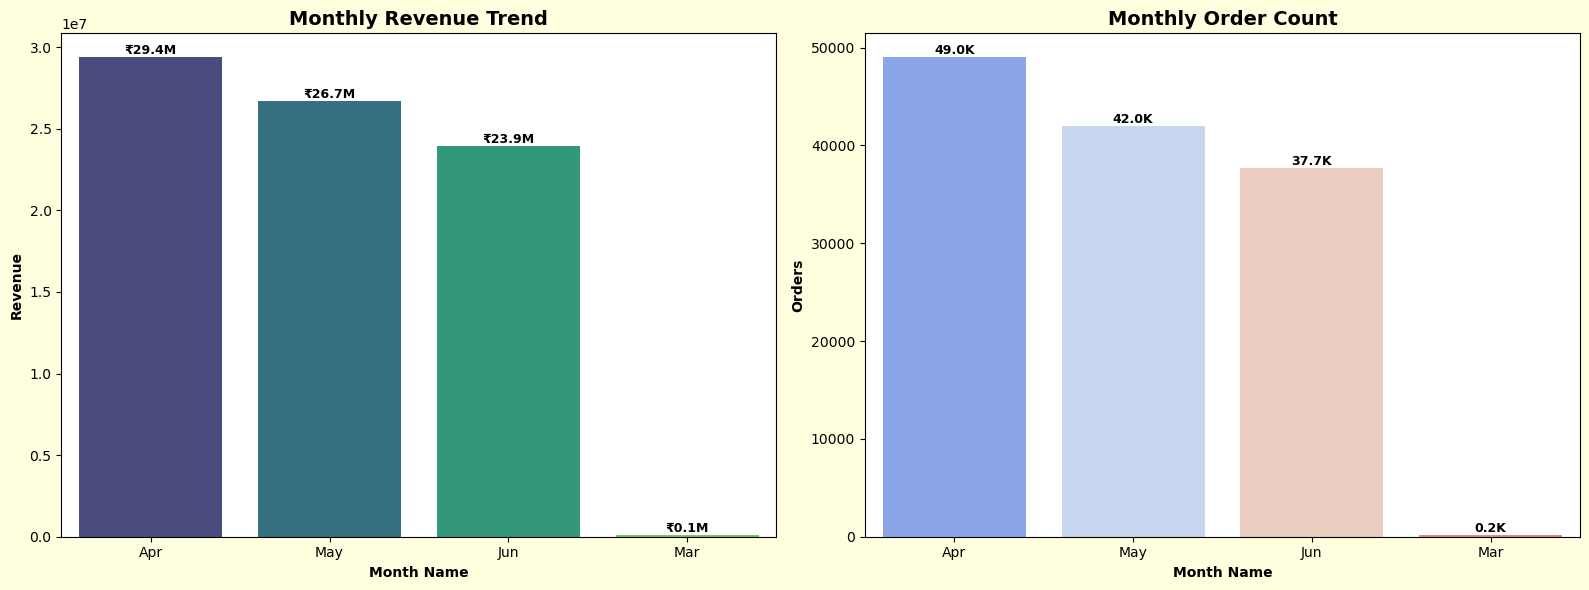

In [285]:
# Create Month name Column 
df['Month_Name']=df['Date'].dt.strftime('%b')
# Bar plot to show trend 
month_rev=df.groupby('Month_Name')['Amount'].sum().sort_values(ascending=False).reset_index()
month_count=df.groupby('Month_Name')['Order_Id'].count().sort_values(ascending=False).reset_index()
fig,axes=plt.subplots(1,2,figsize=(16,6),facecolor='lightyellow')
# First plot
sns.barplot(data=month_rev,x='Month_Name',y='Amount',palette='viridis',ax=axes[0])
axes[0].set_title('Monthly Revenue Trend',fontsize=14,fontweight='bold')
axes[0].set_xlabel('Month Name',fontweight='bold')
axes[0].set_ylabel('Revenue',fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f"₹{p.get_height()/1e6:.1f}M",
                    (p.get_x() + p.get_width()/2,p.get_height()),
                    ha='center',va='bottom',fontsize=9,fontweight='bold')
# Second Plot
sns.barplot(data=month_count,x='Month_Name',y='Order_Id',palette='coolwarm',ax=axes[1])
axes[1].set_title('Monthly Order Count',fontsize=14,fontweight='bold')
axes[1].set_xlabel('Month Name',fontweight='bold')
axes[1].set_ylabel('Orders',fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()/1000:.1f}K",
                    (p.get_x() + p.get_width()/2,p.get_height()),
                    ha='center',va='bottom',fontsize=9,fontweight='bold')
plt.tight_layout() 
plt.show()

#### CELL 5- Fulfilment Type Revenue

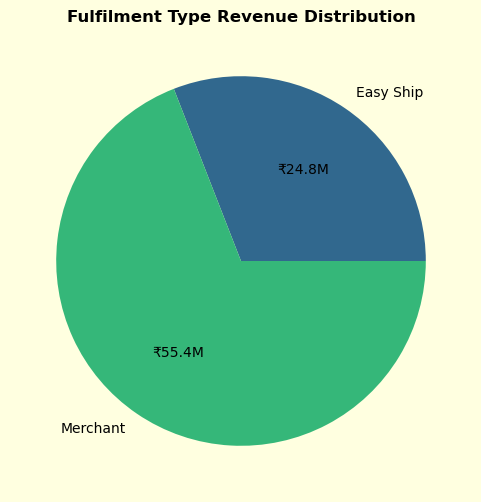

In [286]:
rev=df.groupby('Fulfilled_By')['Amount'].sum().reset_index()
plt.figure(figsize=(6,6),facecolor='lightyellow')
plt.pie(rev['Amount'],labels=rev['Fulfilled_By'],
        colors=sns.color_palette('viridis',len(rev)),
        autopct=(lambda x: f'₹{x * rev["Amount"].sum() / 100 / 1e6:.1f}M'))
plt.title('Fulfilment Type Revenue Distribution',fontweight='bold')
plt.show()

## SECTION 2 — Category & Product Analysis

This section Contains:
- Which product categories drive the most revenue
- What sizes are most popular
- What is the average order value per category
- How does B2B vs B2C split across categories

#### CELL 1 -  Revenue & Orders By Category 

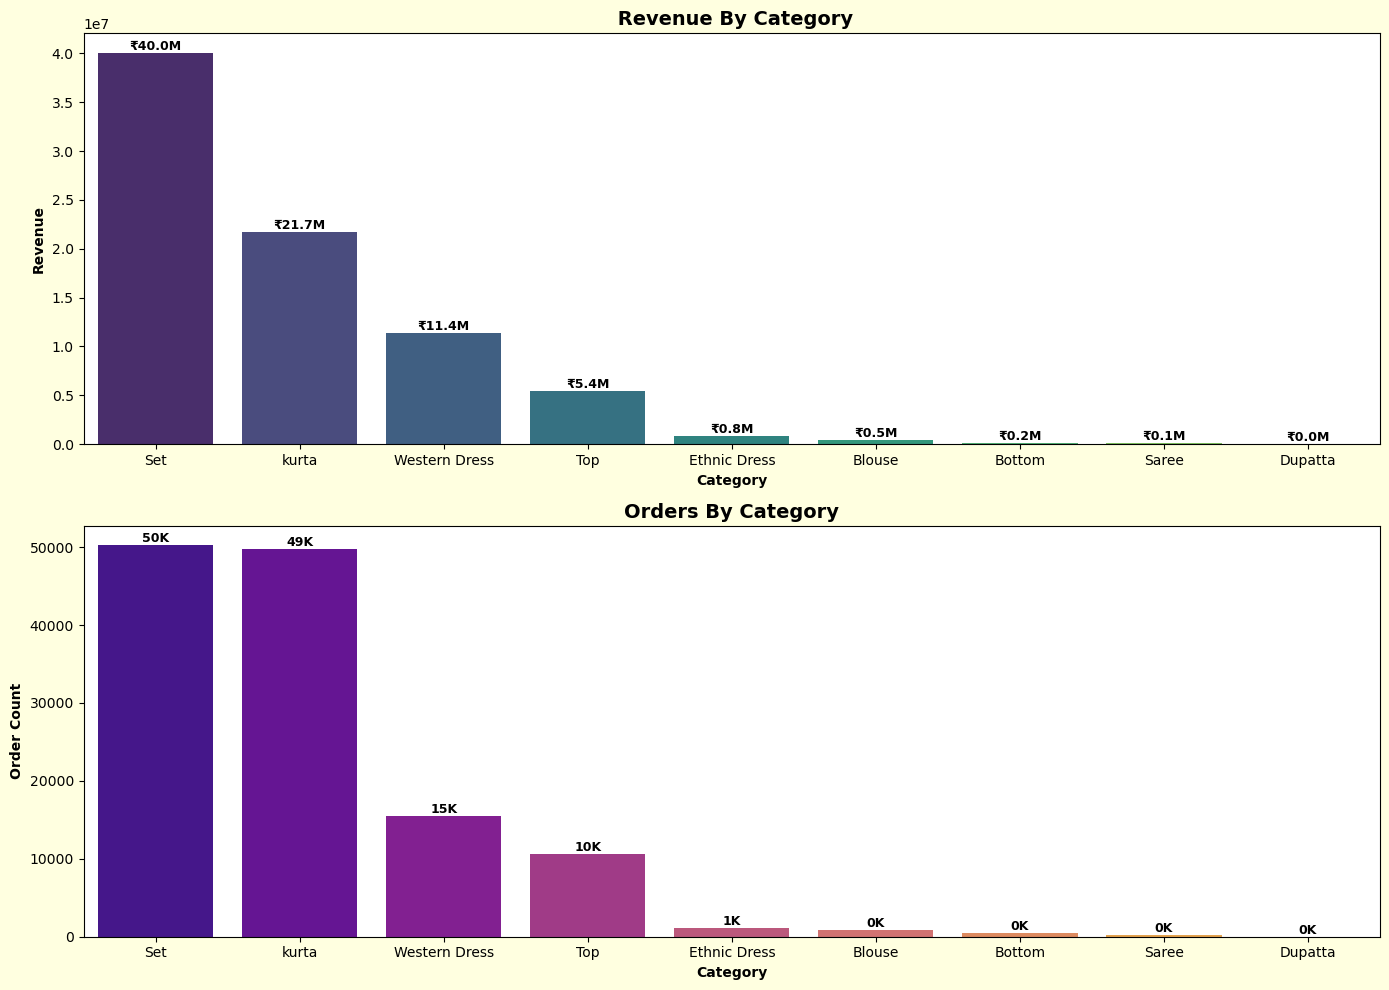

In [287]:
cat_df=df.groupby('Category').agg(
    Revenue=('Amount','sum'),
    orders=('Order_Id','count')).reset_index().sort_values(by=['Revenue','orders'],ascending=[False,False])
fig,axes=plt.subplots(2,1,figsize=(14,10),facecolor='lightyellow')
# First plot
sns.barplot(data=cat_df,x='Category',y='Revenue',order=cat_df['Category'],palette='viridis',ax=axes[0])
axes[0].set_title(' Revenue By Category',fontsize=14,fontweight='bold')
axes[0].set_ylabel('Revenue',fontweight='bold')
axes[0].set_xlabel('Category',fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'₹{p.get_height()/1e6:.1f}M',
                     (p.get_x()+p.get_width()/2,p.get_height()),
                     ha='center',va='bottom',fontweight='bold',fontsize=9)
# Second plot
sns.barplot(data=cat_df,x='Category',y='orders',order=cat_df['Category'],palette='plasma',ax=axes[1])
axes[1].set_title('Orders By Category',fontsize=14,fontweight='bold')
axes[1].set_xlabel('Category',fontweight='bold')
axes[1].set_ylabel('Order Count',fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()/1000)}K',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.tight_layout() 
plt.show()

#### CELL 2 - Orders By Size

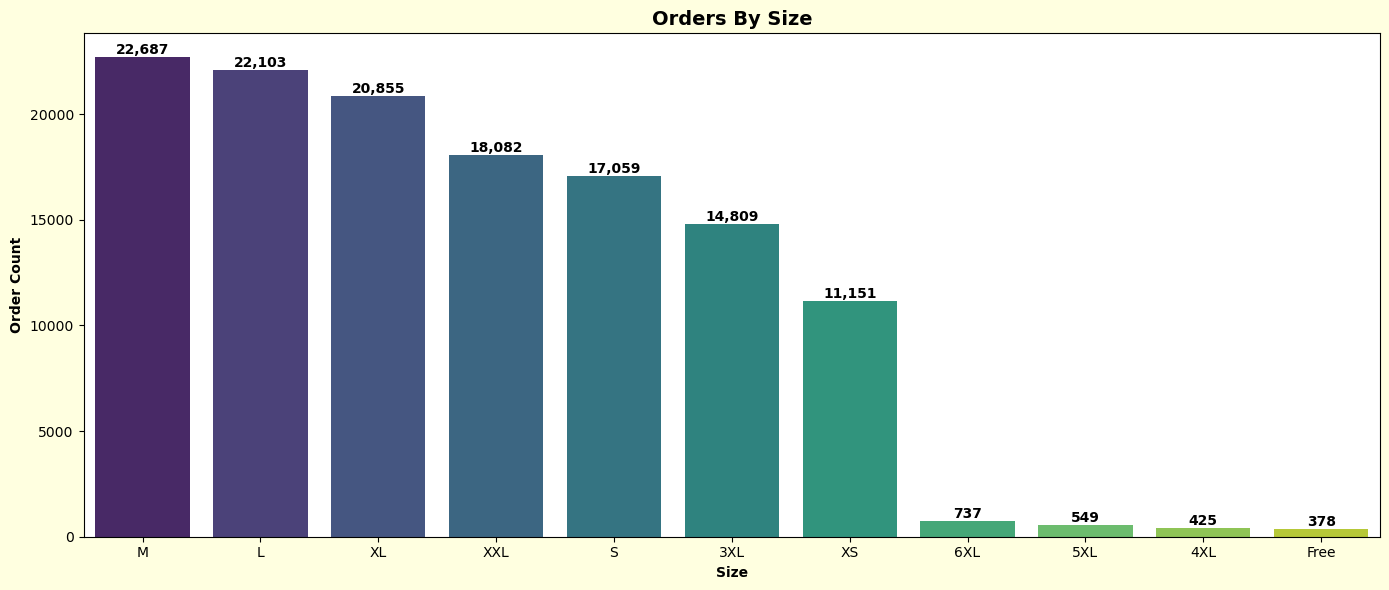

In [288]:
size_dist=df.groupby('Size')['Order_Id'].count().sort_values(ascending=False).reset_index()
plt.figure(figsize=(14,6),facecolor='lightyellow')
ax=sns.barplot(data=size_dist,x='Size',y='Order_Id',palette='viridis',order=size_dist['Size'])
plt.title('Orders By Size',fontsize=14,fontweight='bold')
plt.xlabel('Size',fontweight='bold')
plt.ylabel('Order Count',fontweight='bold')
for i in ax.patches:
    ax.annotate(f'{int(i.get_height()):,}',
                (i.get_x()+i.get_width()/2,i.get_height()),
                ha='center',va='bottom',fontweight='bold')
plt.tight_layout()
plt.show()

#### CELL 3 - Average order value per category

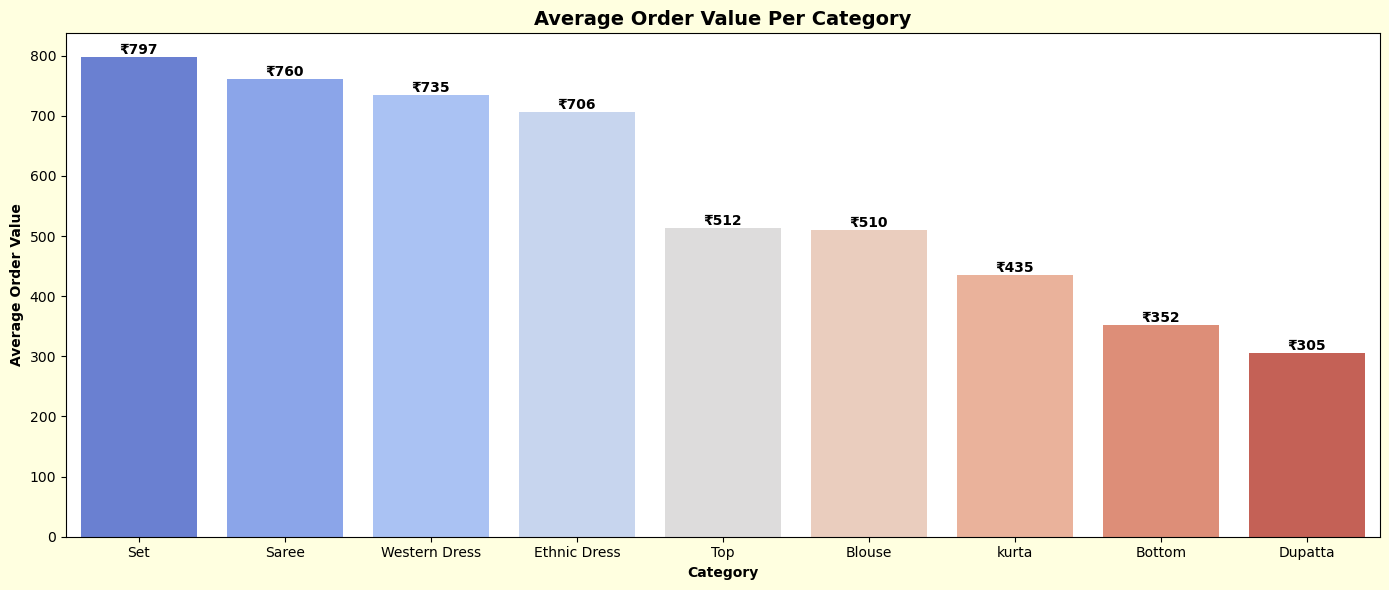

In [289]:
cat_avg=df.groupby('Category')['Amount'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(14,6),facecolor='lightyellow')
ax=sns.barplot(data=cat_avg,x='Category',y='Amount',palette='coolwarm',order=cat_avg['Category'])
plt.title('Average Order Value Per Category',fontsize=14, fontweight='bold')
plt.xlabel('Category',fontweight='bold')
plt.ylabel('Average Order Value',fontweight='bold')
for p in ax.patches:
    ax.annotate(f'₹{int(p.get_height()):,}',
               (p.get_x()+p.get_width()/2,p.get_height()),
                ha='center',va='bottom',fontweight='bold')
plt.tight_layout() 
plt.show()

####  CELL 4 -B2B vs B2C Revenue by Category

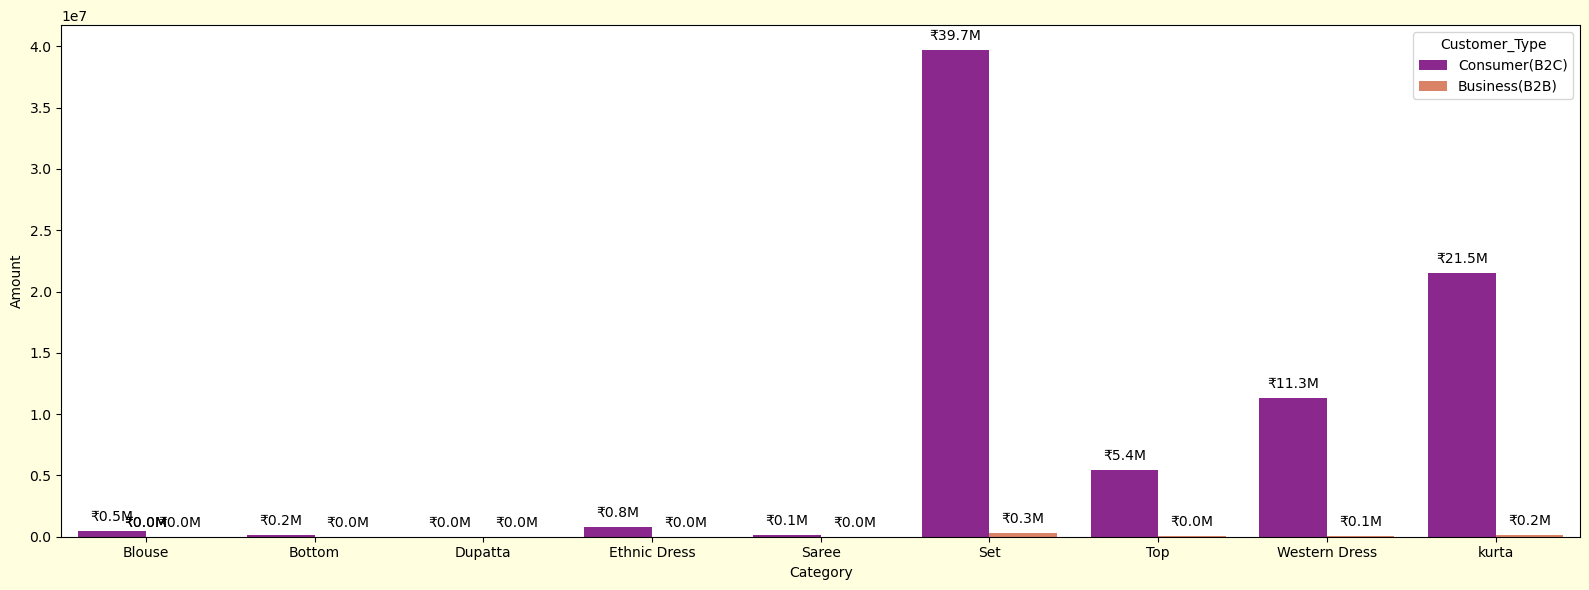

----------------------------------------------------------------------


,Category,Customer_Type,Amount
0,Blouse,Consumer(B2C),469435.18
1,Blouse,Business(B2B),3143.00
2,Bottom,Consumer(B2C),153557.31
3,Bottom,Business(B2B),1595.67
4,Dupatta,Consumer(B2C),915.00
5,Dupatta,Business(B2B),0.00
6,Ethnic Dress,Consumer(B2C),805319.47
7,Ethnic Dress,Business(B2B),12682.19
8,Saree,Consumer(B2C),123082.76
9,Saree,Business(B2B),1651.00


In [352]:
# Create new column since B2B contains boolean value
df['Customer_Type']=df['B2B'].apply(lambda x: 'Business(B2B)' if x else 'Consumer(B2C)')
b2b_distribution=df.groupby(['Category','Customer_Type'])['Amount'].sum().reset_index().sort_values(by=['Category','Amount'],ascending= [True,False])
# bar chart
plt.figure(figsize=(16,6),facecolor='lightyellow')
ax=sns.barplot(data=b2b_distribution,x='Category',y='Amount',hue='Customer_Type',palette='plasma',order=b2b_distribution['Category'])
for p in ax.patches:
    ax.annotate(f'₹{p.get_height()/1e6:.1f}M',
                (p.get_x()+p.get_width()/2,p.get_height()),
                ha='center',va='bottom',
               xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()
print('-'*70)
display(b2b_distribution)

#### CELL 5- B2B vs B2C Order & Revenue Contribution

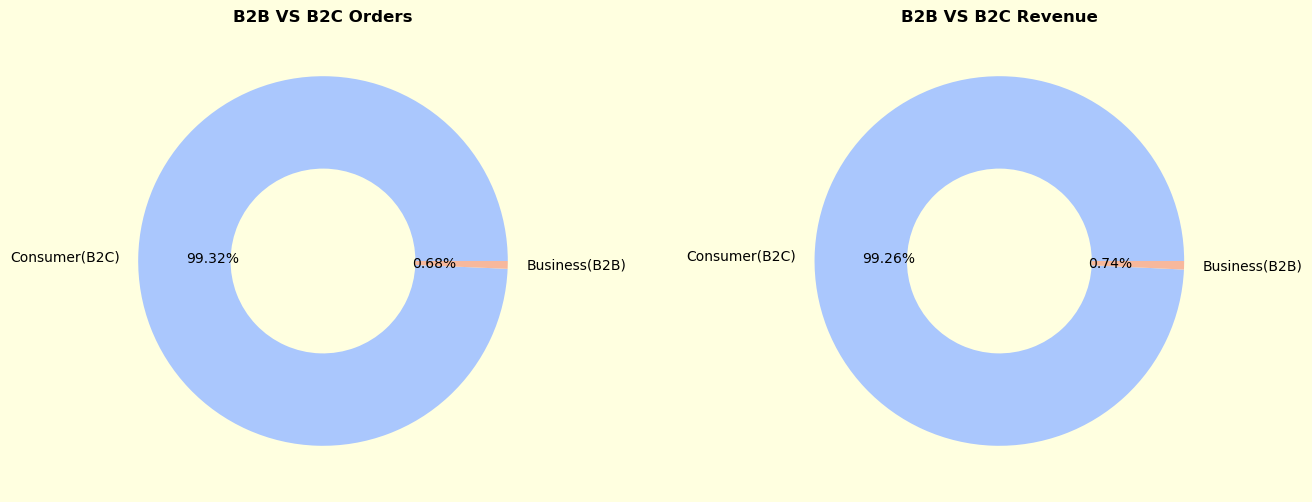

In [311]:
b2b_rev=df.groupby('Customer_Type')['Amount'].sum().reset_index()
b2b_order=df.groupby('Customer_Type')['Order_Id'].count().reset_index()
# Donut Chart to Show this distributions
fig,axes=plt.subplots(1,2,figsize=(16,6),facecolor='lightyellow')
axes[0].pie(b2b_order['Order_Id'],labels=b2b_order['Customer_Type'],autopct='%1.2f%%',
            colors=sns.color_palette('coolwarm',len(b2b_order)),
            wedgeprops=dict(width=(0.5)))
axes[0].set_title('B2B VS B2C Orders',fontweight='bold')
axes[1].pie(b2b_rev['Amount'],labels=b2b_rev['Customer_Type'],autopct='%1.2f%%',
            colors=sns.color_palette('coolwarm',len(b2b_rev)),
            wedgeprops=dict(width=(0.5)))
axes[1].set_title('B2B VS B2C Revenue',fontweight='bold')
plt.show()

## SECTION 3 — Geographic Analysis

This section Contains:
- Which states generate the most revenue & orders
- Which cities are top performers
- How does order volume distribute across India
- Are there regional patterns in category preference

#### CELL 1- Top 15 State By Revenue

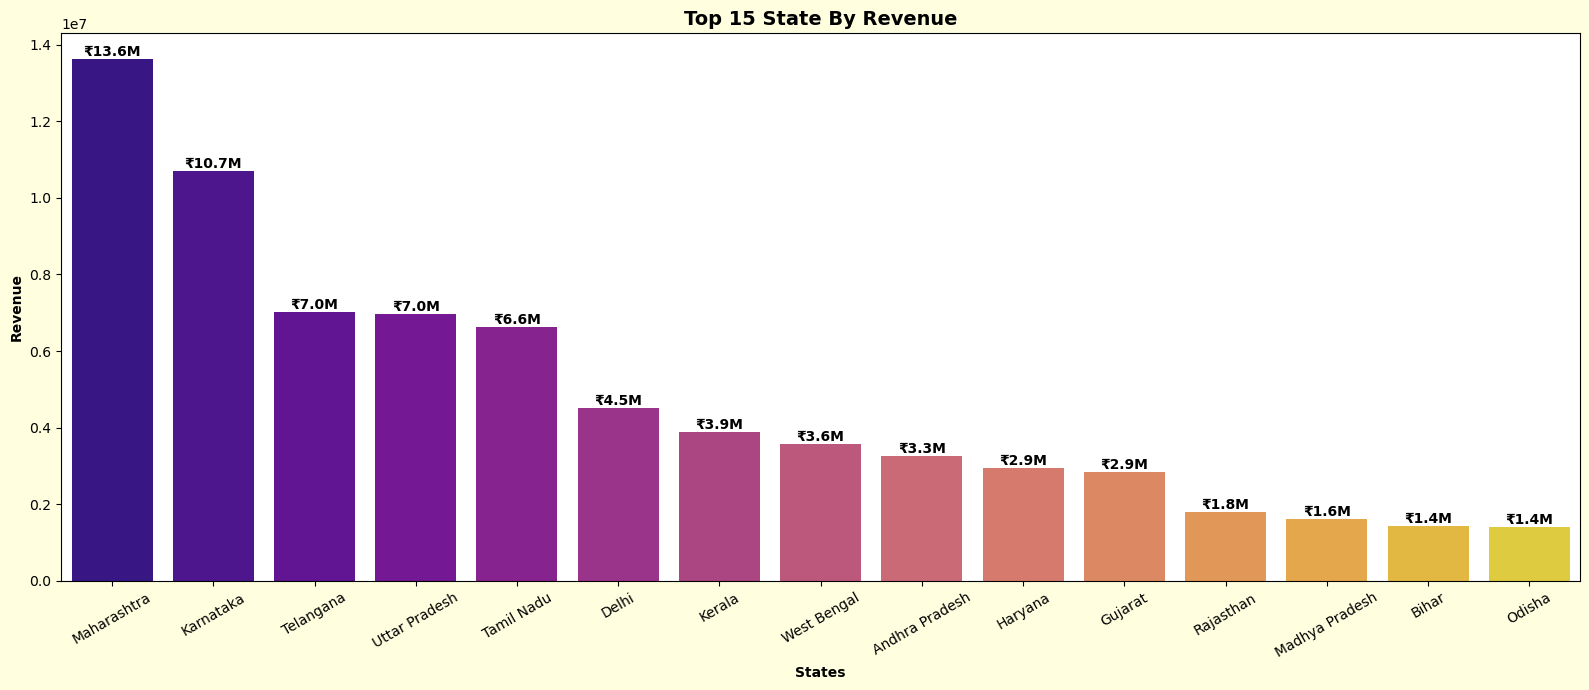

In [292]:
top_state=df.groupby('Ship_State')['Amount'].sum().sort_values(ascending= False).head(15).reset_index()
plt.figure(figsize=(16,7),facecolor='lightyellow')
ax=sns.barplot(data=top_state,x='Ship_State',y='Amount',palette='plasma',order=top_state['Ship_State'])
plt.title('Top 15 State By Revenue',fontsize=14, fontweight='bold')
plt.xlabel('States',fontweight='bold')
plt.ylabel('Revenue',fontweight='bold')
plt.xticks(rotation=30)
for p in ax.patches:
    ax.annotate(f'₹{p.get_height()/1e6:.1f}M',
               (p.get_x()+p.get_width()/2,p.get_height()),
                ha='center',va='bottom',fontweight='bold')
plt.tight_layout() 
plt.show()

#### CELL 2 - Top 15 state by orders

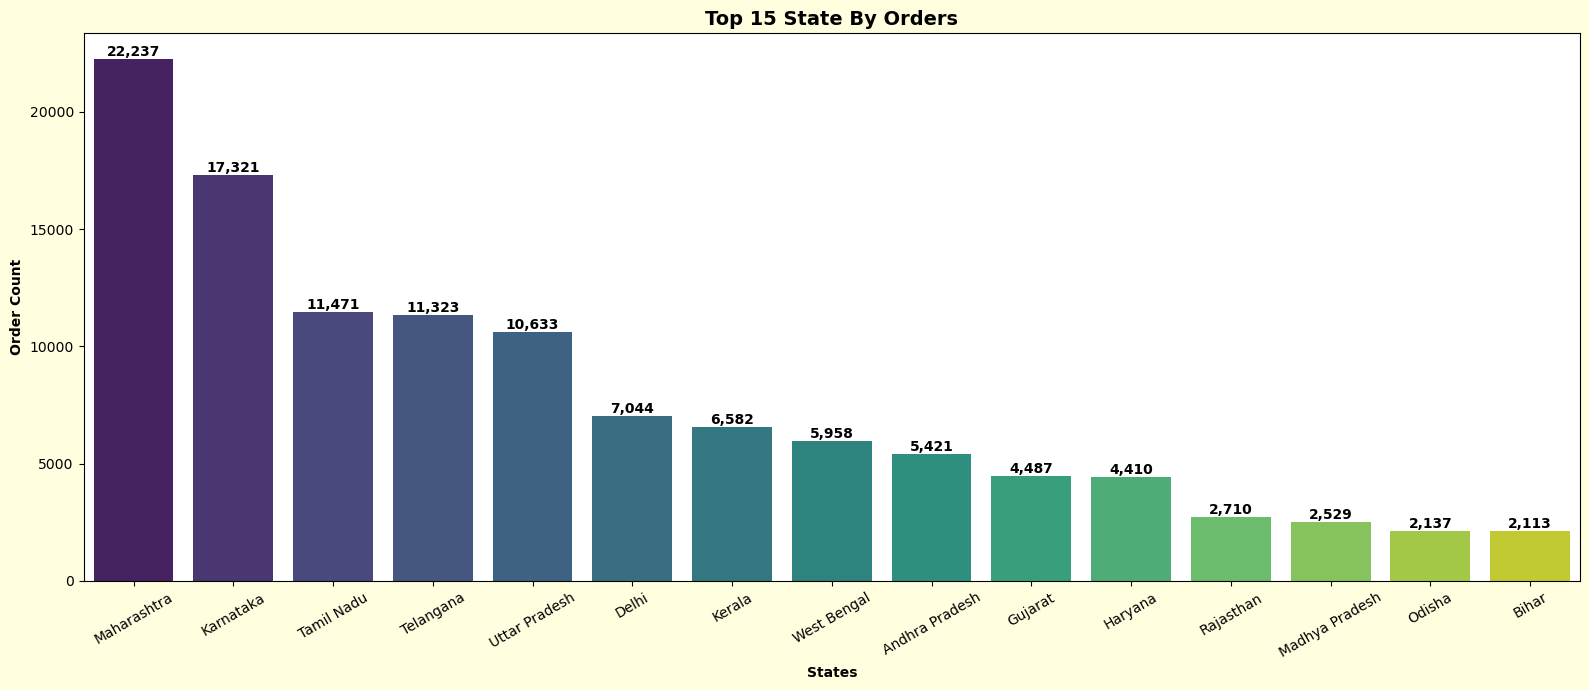

In [293]:
state_order=df.groupby('Ship_State')['Order_Id'].count().sort_values(ascending= False).head(15).reset_index()
plt.figure(figsize=(16,7),facecolor='lightyellow')
ax=sns.barplot(data=state_order,x='Ship_State',y='Order_Id',palette='viridis',order=state_order['Ship_State'])
plt.title('Top 15 State By Orders',fontsize=14, fontweight='bold')
plt.xlabel('States',fontweight='bold')
plt.ylabel('Order Count',fontweight='bold')
plt.xticks(rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
               (p.get_x()+p.get_width()/2,p.get_height()),
                ha='center',va='bottom',fontweight='bold')
plt.tight_layout() 
plt.show()

#### CELL 3 - Top States: Revenue vs Orders Scatter 

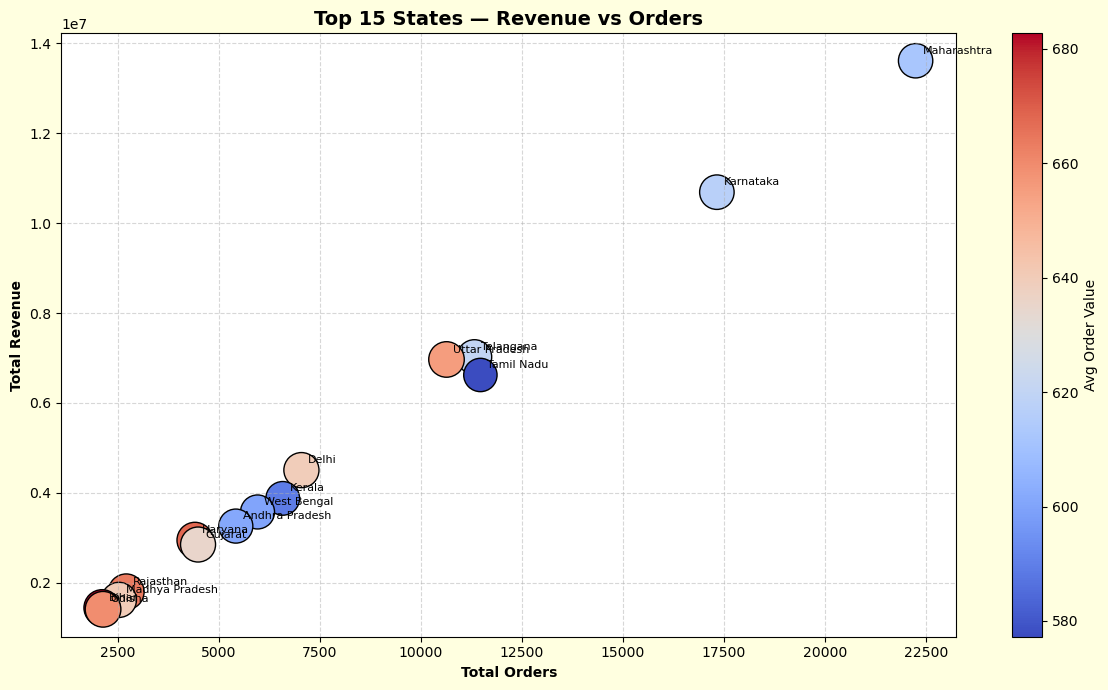

In [294]:
State_dist=df.groupby('Ship_State').agg(
    Revenue=('Amount','sum'),
    Orders=('Order_Id','count'),
    Avg=('Amount','mean')).sort_values( by='Revenue',ascending=False).head(15).reset_index()
fig,ax=plt.subplots(figsize=(12,7),facecolor='lightyellow')
sp=ax.scatter(State_dist['Orders'],State_dist['Revenue'],
           s=State_dist['Avg'],
           c=State_dist['Avg'],
           cmap='coolwarm',edgecolors='black')
for index,row in State_dist.iterrows():
    ax.annotate(row['Ship_State'],(row['Orders'],row['Revenue']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)
plt.colorbar(sp, ax=ax, label='Avg Order Value')
ax.set_title('Top 15 States — Revenue vs Orders', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Orders', fontweight='bold')
ax.set_ylabel('Total Revenue', fontweight='bold')
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### CELL 4 - Top 10 City by Revenue

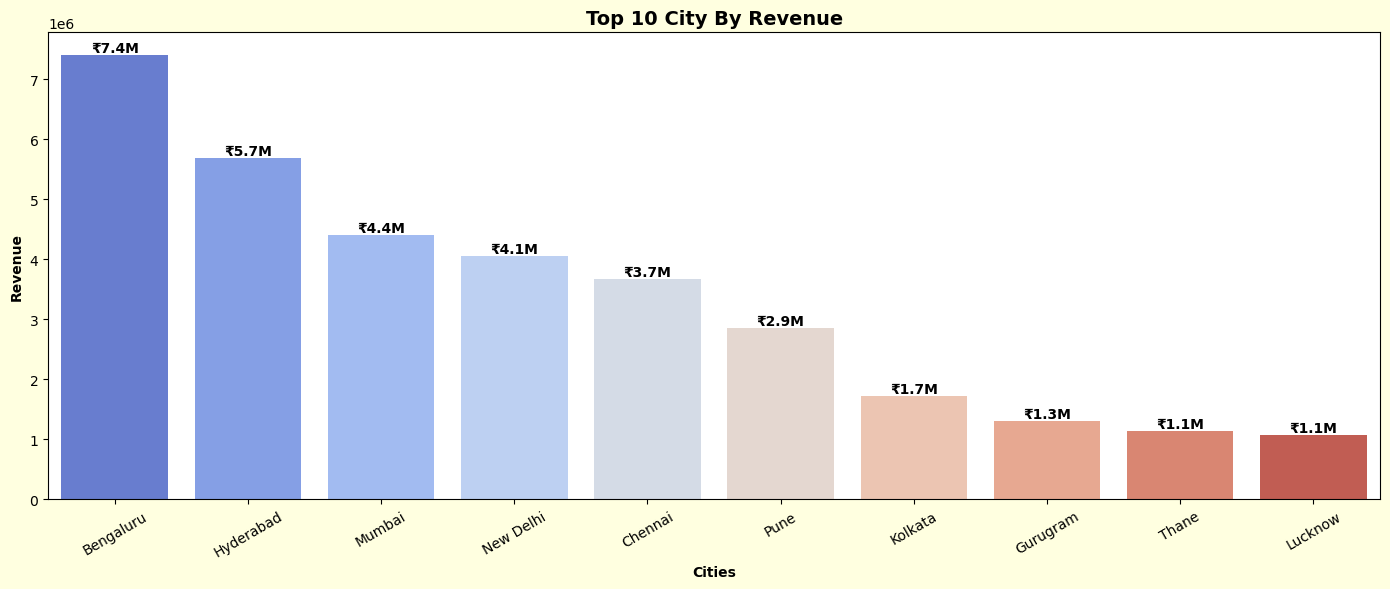

In [295]:
city_rev=df.groupby('Ship_City')['Amount'].sum().sort_values(ascending= False).head(10).reset_index()
plt.figure(figsize=(14,6),facecolor='lightyellow')
ax=sns.barplot(data=city_rev,x='Ship_City',y='Amount',order=city_rev['Ship_City'],palette='coolwarm')
plt.title('Top 10 City By Revenue',fontsize=14, fontweight='bold')
plt.xlabel('Cities',fontweight='bold')
plt.ylabel('Revenue',fontweight='bold')
plt.xticks(rotation=30)
for p in ax.patches:
    ax.annotate(f'₹{p.get_height()/1e6:.1f}M',
               (p.get_x()+p.get_width()/2,p.get_height()),
                ha='center',va='bottom',fontweight='bold')
plt.tight_layout() 
plt.show()

#### CELL 5 - Top Cities By Orders

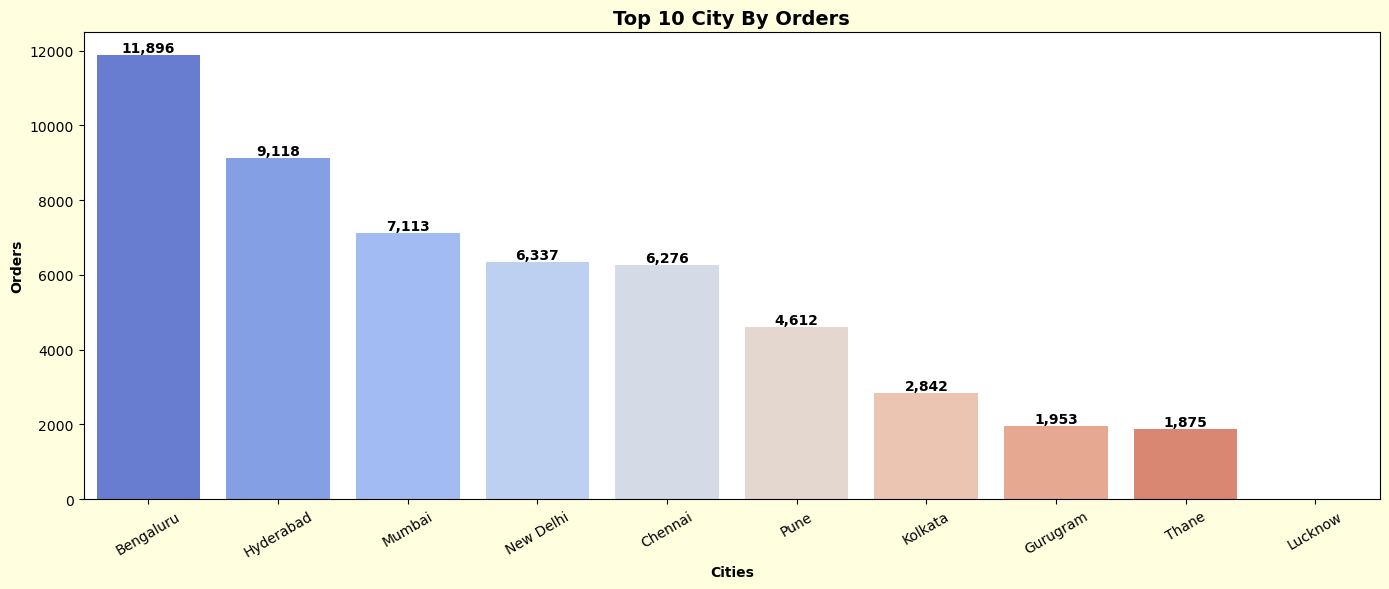

In [296]:
city_orders=df.groupby('Ship_City')['Order_Id'].count().sort_values(ascending= False).head(10).reset_index()
plt.figure(figsize=(14,6),facecolor='lightyellow')
ax=sns.barplot(data=city_orders,x='Ship_City',y='Order_Id',order=city_rev['Ship_City'],palette='coolwarm')
plt.title('Top 10 City By Orders',fontsize=14, fontweight='bold')
plt.xlabel('Cities',fontweight='bold')
plt.ylabel('Orders',fontweight='bold')
plt.xticks(rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
               (p.get_x()+p.get_width()/2,p.get_height()),
                ha='center',va='bottom',fontweight='bold')
plt.tight_layout() 
plt.show()

## SECTION 4 - Distributions
This Section Contains :
-  Order Status Distribution
-  Distribution of Order Amounts: B2B vs B2C
-  Price Distribution by Product Category
-  Correlation Matrix

####  CELL 1 -  Order Status Distribution

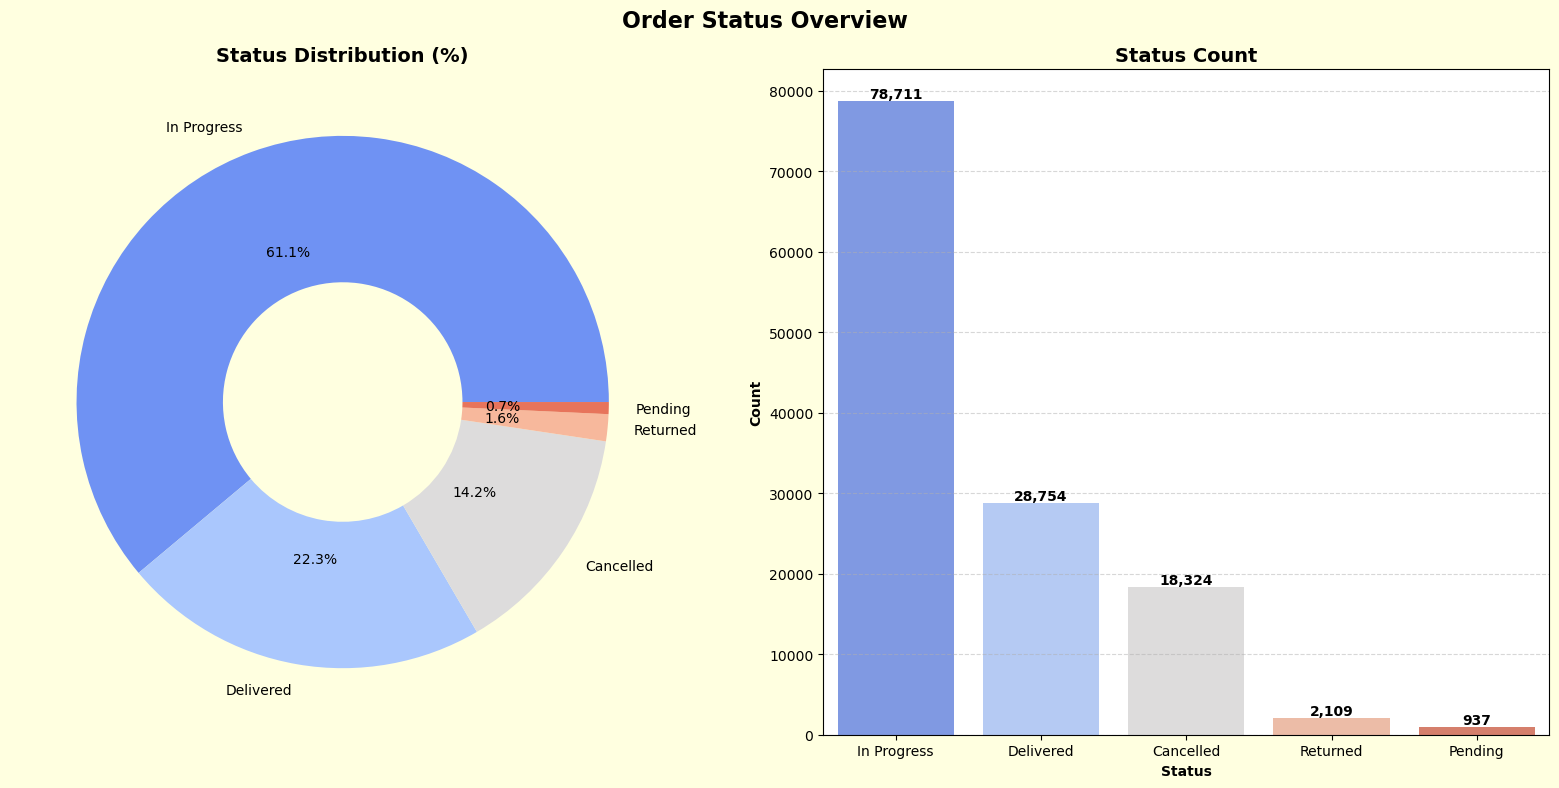

In [297]:
stat=df['Status'].value_counts().sort_values(ascending=False).reset_index()
fig,axes=plt.subplots(1,2,figsize=(16,8),facecolor='lightyellow')
sns.barplot(data=stat,x='Status',y='count',palette='coolwarm',order=stat['Status'],ax=axes[1])
axes[1].set_xlabel('Status',fontweight='bold')
axes[1].set_ylabel('Count',fontweight='bold')
axes[1].set_title('Status Count',fontsize=14, fontweight='bold')
for r in axes[1].patches:
    axes[1].annotate(f'{int(r.get_height()):,}',
                (r.get_x()+r.get_width()/2,r.get_height()),
                ha='center',va='bottom',fontweight='bold')
axes[1].grid(axis='y',linestyle='--',alpha=0.5)
axes[0].pie(stat['count'],labels=stat['Status'], autopct='%1.1f%%',
            colors=sns.color_palette('coolwarm',len(stat)),
            wedgeprops=dict(width=0.55))
axes[0].set_title('Status Distribution (%)',fontsize=14, fontweight='bold')
plt.suptitle('Order Status Overview',fontsize=16, fontweight='bold')
plt.tight_layout() 
plt.show()


#### CELL 2 - Distribution of Order Amounts: B2B vs B2C

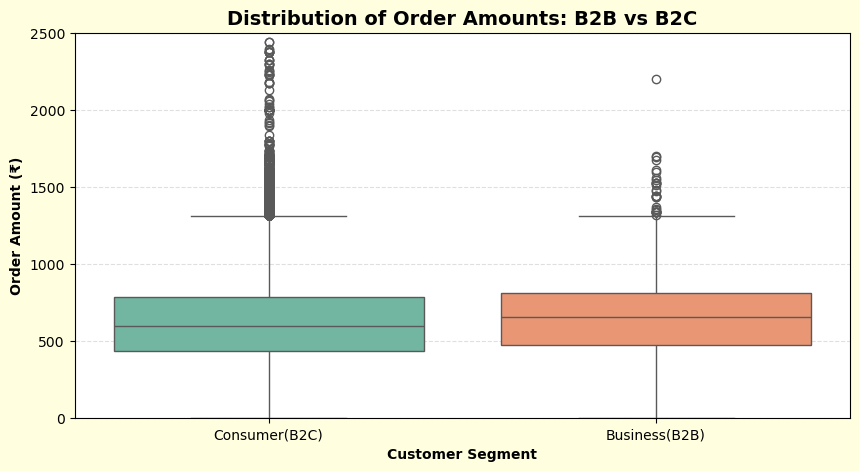

In [312]:
plt.figure(figsize=(10, 5), facecolor='lightyellow')

# Create the boxplot
ax = sns.boxplot(data=df, x='Customer_Type', y='Amount', palette='Set2')

# Since Sales data often has huge outliers, we limit the Y-axis 
plt.ylim(0, 2500) 

plt.title('Distribution of Order Amounts: B2B vs B2C', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontweight='bold')
plt.ylabel('Order Amount (₹)', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

#### CELL 3 - Price Distribution by Product Category

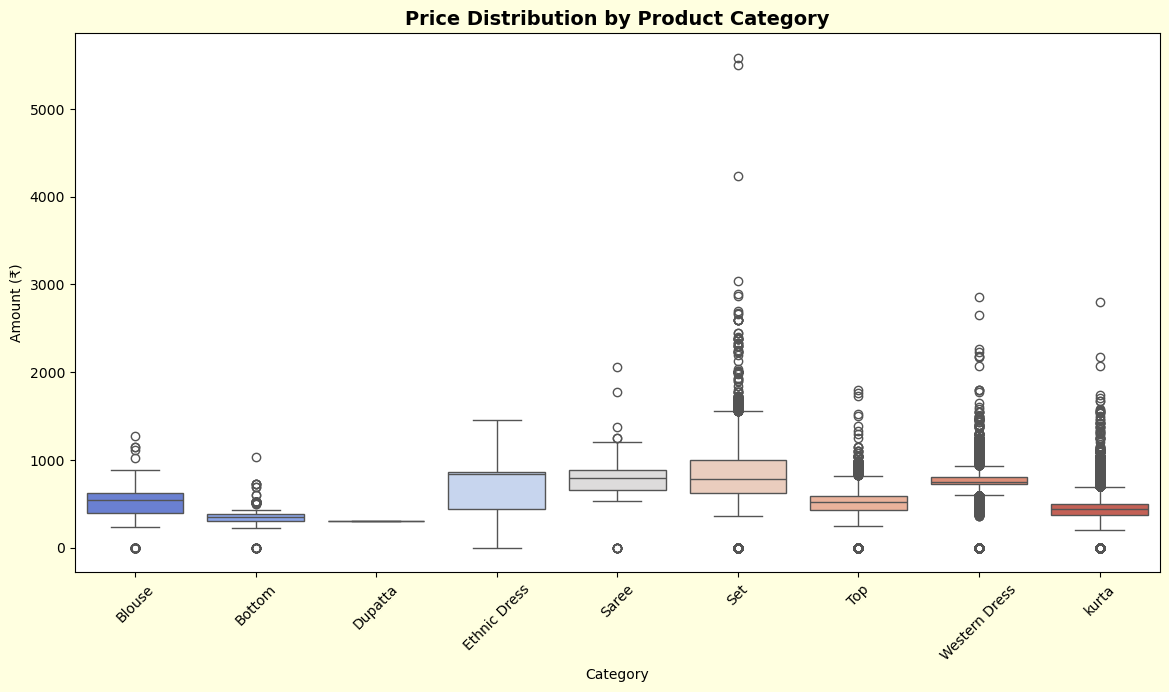

In [299]:
plt.figure(figsize=(14, 7), facecolor='lightyellow')

sns.boxplot(data=df, x='Category', y='Amount', palette='coolwarm')

plt.title('Price Distribution by Product Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Amount (₹)')
plt.show()

#### CELL 4 - Correlation Matrix

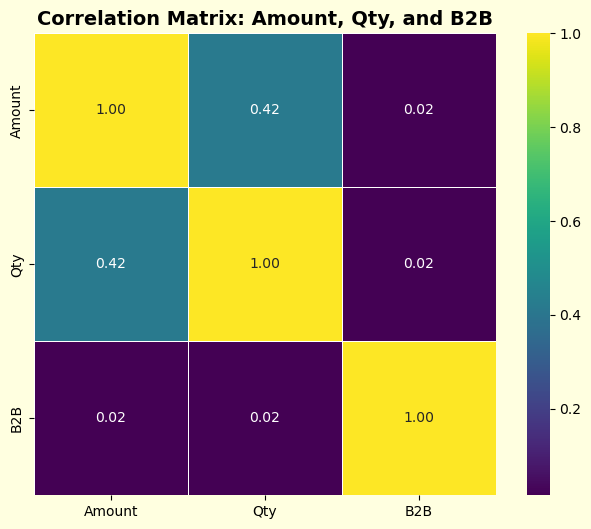

In [347]:
numeric_df = df[['Amount', 'Qty', 'B2B']]

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Create the Heatmap
plt.figure(figsize=(8, 6), facecolor='lightyellow')
sns.heatmap(corr_matrix, 
            annot=True,          
            cmap='viridis',     
            fmt='.2f',           
            linewidths=0.5, 
            square=True)

plt.title('Correlation Matrix: Amount, Qty, and B2B', fontsize=14, fontweight='bold')
plt.show()

## SECTION 5 — Order Status & Cancellation Analysis

This section Contains:
- What percentage of orders are cancelled vs delivered
- Which categories have the highest cancellation rate
- Which states cancel the most
- How much revenue is lost to cancellations
- Does fulfilment type affect cancellation rate

#### CELL 1 - Order Fulfillment Status Distribution

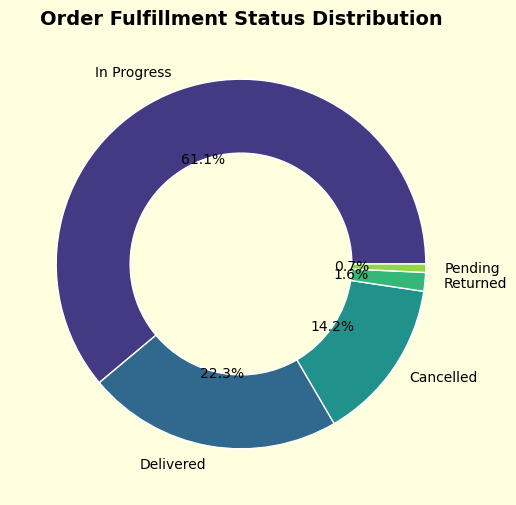

In [335]:
counts=df['Status'].value_counts().reset_index()
plt.figure(figsize=(6, 6), facecolor='lightyellow')
plt.pie(counts['count'],labels=counts['Status'],autopct='%1.1f%%',
        colors=sns.color_palette('viridis',len(counts)),
       wedgeprops=dict(width=0.4,edgecolor='white'))
plt.title('Order Fulfillment Status Distribution', fontsize=14, fontweight='bold')
plt.show()

#### CELL 2 - Cancellation Rate By Category

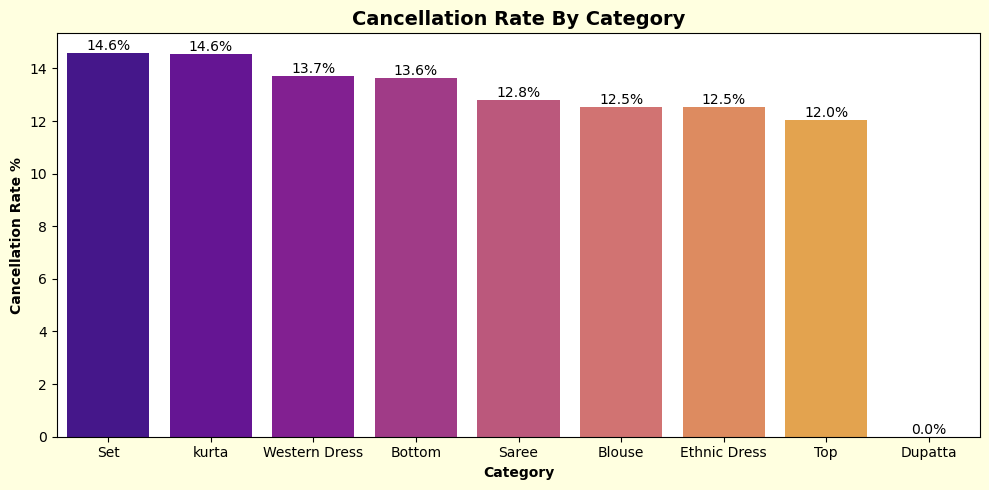

In [300]:
# Create New Column 
df['Check_Cancelled']=df['Status'].apply(lambda x : True if 'Cancelled' in str(x) else False)
cancel_cat=df.groupby('Category')['Check_Cancelled'].mean().mul(100).sort_values(ascending=False).reset_index()
# Barplot to show trend
plt.figure(figsize=(10,5),facecolor='lightyellow')
ax=sns.barplot(data=cancel_cat,x='Category',y='Check_Cancelled',palette='plasma',order=cancel_cat['Category'])
plt.title('Cancellation Rate By Category',fontsize=14,fontweight='bold')
plt.xlabel('Category',fontweight='bold')
plt.ylabel('Cancellation Rate %',fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                     (p.get_x()+p.get_width()/2,p.get_height()),
                     ha='center',va='bottom')
plt.tight_layout()
plt.show()

#### CELL 3- Top 15 State By Cancellation Rate

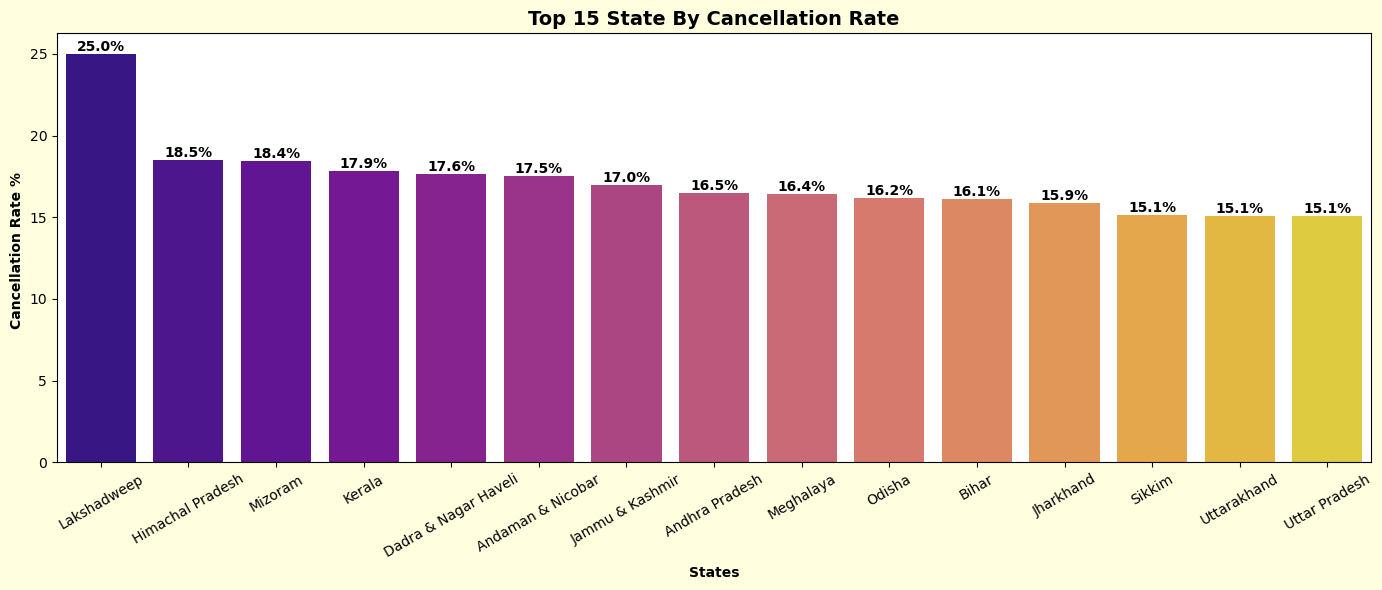

In [308]:
cancel_state=df.groupby('Ship_State')['Check_Cancelled'].mean().mul(100).sort_values(ascending=False).head(15).reset_index()
plt.figure(figsize=(14,6),facecolor='lightyellow')
ax=sns.barplot(data=cancel_state,x='Ship_State',y='Check_Cancelled',palette='plasma',order=cancel_state['Ship_State'])
plt.title('Top 15 State By Cancellation Rate',fontsize=14,fontweight='bold')
plt.xlabel('States',fontweight='bold')
plt.ylabel('Cancellation Rate % ',fontweight='bold')
plt.xticks(rotation=30)
for r in ax.patches:
    ax.annotate(f'{r.get_height():.1f}%',
               (r.get_x()+r.get_width()/2,r.get_height()),
               ha='center',va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

#### CELL 4 - Revenue Lost to Cancellations by Category 

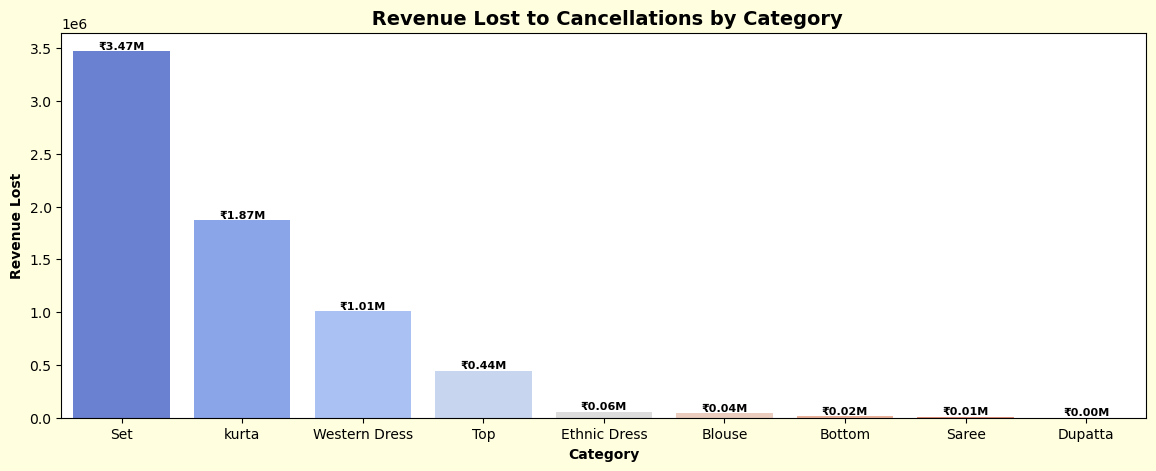

In [309]:
rev_lost=df[df['Status']=='Cancelled'].groupby('Category')['Amount'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(14,5),facecolor='lightyellow')
ax=sns.barplot(data=rev_lost,x='Category',y='Amount',order=rev_lost['Category'],palette='coolwarm')
for p in ax.patches:
    ax.annotate(f'₹{p.get_height()/1e6:.2f}M',
                (p.get_x()+p.get_width()/2,p.get_height()),
                ha='center',va='bottom',fontweight='bold',fontsize=8)
plt.title(' Revenue Lost to Cancellations by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category',fontweight='bold')
plt.ylabel('Revenue Lost',fontweight='bold')
plt.show()

In [337]:
df.columns

Index(['Index', 'Order_Id', 'Date', 'Status', 'Fulfilment', 'Sales_Channel',
       'Ship_Service_Level', 'Style', 'Sku', 'Category', 'Size', 'Asin',
       'Courier_Status', 'Qty', 'Currency', 'Amount', 'Ship_City',
       'Ship_State', 'Ship_Postal_Code', 'Ship_Country', 'Promotion_Ids',
       'B2B', 'Fulfilled_By', 'Promotion_Type', 'Day_Of_Week', 'Month_Name',
       'Customer_Type', 'Check_Cancelled'],
      dtype='object')

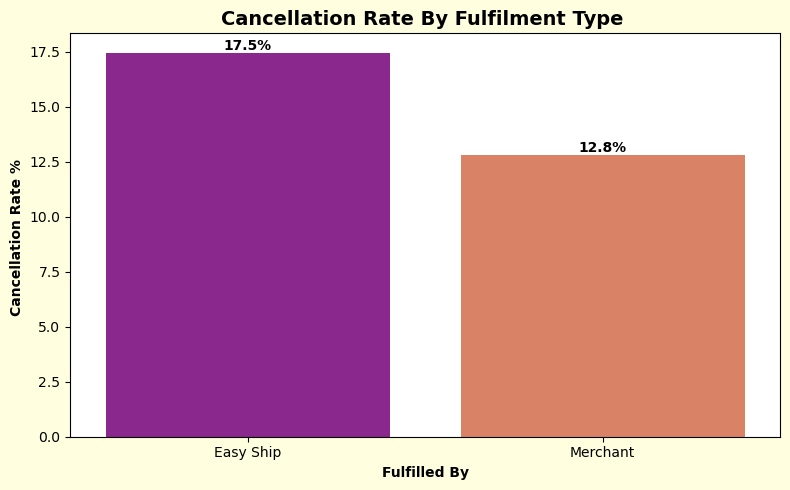

In [343]:
full_cancel_rate=df.groupby('Fulfilled_By')['Check_Cancelled'].mean().mul(100).reset_index()
plt.figure(figsize=(8,5),facecolor='lightyellow')
ax=sns.barplot(data=full_cancel_rate,x='Fulfilled_By',y='Check_Cancelled',palette='plasma',order=full_cancel_rate['Fulfilled_By'])
plt.title('Cancellation Rate By Fulfilment Type ',fontsize=14,fontweight='bold')
plt.xlabel('Fulfilled By',fontweight='bold')
plt.ylabel('Cancellation Rate % ',fontweight='bold')
for r in ax.patches:
    ax.annotate(f'{r.get_height():.1f}%',
               (r.get_x()+r.get_width()/2,r.get_height()),
               ha='center',va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## SECTION 6 - Statistical Test

####  CELL 1 - Chi-Square Test"Is cancellation rate independent of category?"

In [348]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['Category'], df['Check_Cancelled'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'p-value: {p:.4f}')
# p < 0.05 means cancellation DEPENDS on category

p-value: 0.0000


#### CELL 2 - T-Test"Is average order value different for B2B vs B2C?"

In [349]:
from scipy.stats import ttest_ind

b2b = df[df['B2B'] == True]['Amount']
b2c = df[df['B2B'] == False]['Amount']
t, p = ttest_ind(b2b, b2c)
print(f'p-value: {p:.4f}')
# p < 0.05 means B2B and B2C order values are significantly different

p-value: 0.0000


#### CELL 3 -ANOVA Test"Is revenue significantly different across categories?"

In [350]:
from scipy.stats import f_oneway

groups = [df[df['Category'] == cat]['Amount'] for cat in df['Category'].unique()]
f, p = f_oneway(*groups)
print(f'p-value: {p:.4f}')
# p < 0.05 means at least one category is significantly different

p-value: 0.0000


## Final EDA Summary:

In [304]:
print('=' * 60)
print('          COMPLETE EDA — KEY INSIGHTS SUMMARY')
print('=' * 60)

print(' SALES & REVENUE')
print(f'   Total Revenue      : ₹{df["Amount"].sum():,.0f}')
print(f'   Total Orders       : {df["Order_Id"].nunique():,}')
print(f'   Avg Order Value    : ₹{df[df["Amount"]>0]["Amount"].mean():,.0f}')
print(f'   Peak Revenue Day   : {day_rev.loc[day_rev["Amount"].idxmax(), "Date"].date()}')
print(f'   Best Month         : {month_rev.loc[month_rev["Amount"].idxmax(), "Month_Name"]}')

print('  CATEGORY & PRODUCT')
print(f'   Top Category       : {cat_df.iloc[0]["Category"]}')
print(f'   Top Category Rev   : ₹{cat_df.iloc[0]["Revenue"]:,.0f}')
print(f'   Most Popular Size  : {size_dist.iloc[0]["Size"]}')

print('  GEOGRAPHY')
print(f'   Top State (Rev)    : {top_state.iloc[0]["Ship_State"]}')
print(f'   Top State Revenue  : ₹{top_state.iloc[0]["Amount"]:,.0f}')
print(f'   Top City           : {city_rev.iloc[0]["Ship_City"]}')

print(' CANCELLATIONS')
print(f'   Cancellation Rate  : {cancel_rate:.2f}%')
print(f'   Revenue Lost       : ₹{lost_df["Revenue_Lost"].sum():,.0f}')
print(f'   Worst Category     : {cancel_cat.iloc[0]["Category"]} ({cancel_cat.iloc[0]["Check_Cancelled"]:.1f}%)')
print(f'   Worst State        : {cancel_state.iloc[0]["Ship_State"]} ({cancel_state.iloc[0]["Check_Cancelled"]:.1f}%)')

print('=' * 60)
print('             EDA Complete!')
print('=' * 60)

          COMPLETE EDA — KEY INSIGHTS SUMMARY
 SALES & REVENUE
   Total Revenue      : ₹80,130,308
   Total Orders       : 120,349
   Avg Order Value    : ₹661
   Peak Revenue Day   : 2022-05-04
   Best Month         : Apr
  CATEGORY & PRODUCT
   Top Category       : Set
   Top Category Rev   : ₹40,039,912
   Most Popular Size  : M
  GEOGRAPHY
   Top State (Rev)    : Maharashtra
   Top State Revenue  : ₹13,611,061
   Top City           : Bengaluru
 CANCELLATIONS
   Cancellation Rate  : 14.22%
   Revenue Lost       : ₹6,917,254
   Worst Category     : Set (14.6%)
   Worst State        : Lakshadweep (25.0%)
             EDA Complete!
